<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); 
            padding: 40px 50px; border-radius: 12px; margin-bottom: 20px; color: white; font-family: 'Segoe UI', sans-serif;">

  <h1 style="margin: 0 0 8px 0; font-size: 2.4em; font-weight: 700; letter-spacing: -0.5px;">
    Beam Profile &amp; Gouy Phase
  </h1>

  <p style="margin: 0 0 4px 0; font-size: 1.1em; opacity: 0.85; font-weight: 300; letter-spacing: 1px; text-transform: uppercase;">
    LLO HAM6 · WFS36 Sled · 1064 nm
  </p>

  <hr style="border: none; border-top: 1px solid rgba(255,255,255,0.2); margin: 16px 0;">

  <div style="display: flex; justify-content: space-between; align-items: flex-end;">
    <div>
      <p style="margin: 0; font-size: 1.0em; opacity: 0.9;"><strong>Authors:</strong> Katie Gray &amp; Maryrose Barrios</p>
    </div>
    <div style="text-align: right;">
      <p style="margin: 0; font-size: 1.1em; opacity: 0.75; font-weight: 300;">April 15, 2026</p>
    </div>
  </div>

</div>

Models vs as-built for the paths using the document D2100618-v1 distances and measured input beam parameter with the Phasics camera

q_in: w0=0.3315 mm, z=-211.7383 mm, w=0.3958 mm, Rc=-709.0915 mm


,z,w0,zr,w,RoC,S,Acc. Gouy,q
input.p1.i,0 m,331.52 um,324.51 mm,395.85 um,-709.09 mm,-1.4103 D,0°,-0.212 + 0.325j
input.p2.o,0 m,331.52 um,324.51 mm,395.85 um,-709.09 mm,-1.4103 D,0°,-0.212 + 0.325j
L3.p1.i,1 mm,331.52 um,324.51 mm,395.29 um,-710.45 mm,-1.4076 D,124.01m°,-0.211 + 0.325j
L3.p2.o,1 mm,189.12 um,105.6 mm,395.29 um,-251.37 mm,-3.9782 D,124.01m°,-0.194 + 0.106j
R5.p1.i,256.79 mm,189.12 um,105.6 mm,219.27 um,241.95 mm,4.133 D,91.942°,0.062 + 0.106j
R5.p2.o,256.79 mm,189.12 um,105.6 mm,219.27 um,241.95 mm,4.133 D,91.942°,0.062 + 0.106j
PD1_det.p1.i,348.19 mm,189.12 um,105.6 mm,333.46 um,226.08 mm,4.4232 D,116.99°,0.153 + 0.106j
PD1_det.p2.o,348.19 mm,189.12 um,105.6 mm,333.46 um,226.08 mm,4.4232 D,116.99°,0.153 + 0.106j



PD1 predicted beam size : 0.3335 mm


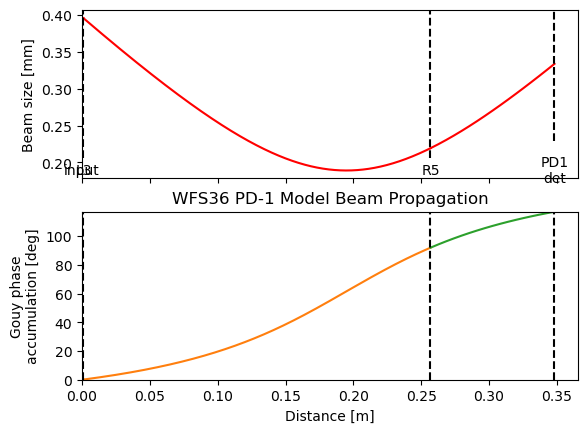

,z,w0,zr,w,RoC,S,Acc. Gouy,q
input.p1.i,0 m,331.52 um,324.51 mm,395.85 um,-709.09 mm,-1.4103 D,0°,-0.212 + 0.325j
input.p2.o,0 m,331.52 um,324.51 mm,395.85 um,-709.09 mm,-1.4103 D,0°,-0.212 + 0.325j
L3.p1.i,1 mm,331.52 um,324.51 mm,395.29 um,-710.45 mm,-1.4076 D,124.01m°,-0.211 + 0.325j
L3.p2.o,1 mm,189.12 um,105.6 mm,395.29 um,-251.37 mm,-3.9782 D,124.01m°,-0.194 + 0.106j
R5.p1.i,280 mm,189.12 um,105.6 mm,242.96 um,216.11 mm,4.6272 D,100.43°,0.085 + 0.106j
R5.p2.o,280 mm,189.12 um,105.6 mm,242.96 um,216.11 mm,4.6272 D,100.43°,0.085 + 0.106j
PD1_det.p1.i,523 mm,189.12 um,105.6 mm,617.38 um,362.15 mm,2.7613 D,133.7°,0.328 + 0.106j
PD1_det.p2.o,523 mm,189.12 um,105.6 mm,617.38 um,362.15 mm,2.7613 D,133.7°,0.328 + 0.106j



PD1 predicted beam size : 0.6174 mm


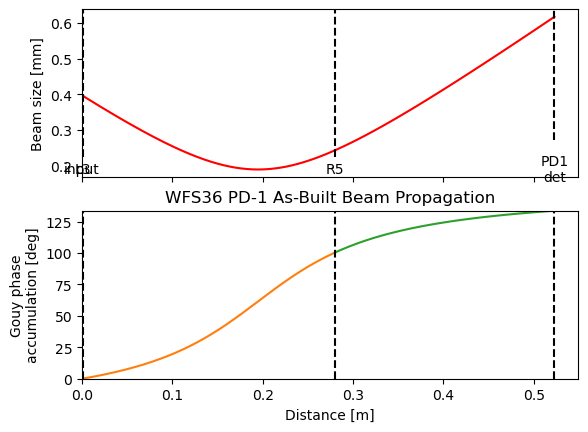

In [77]:
'''
WFS36 Gouy phase check for LLO HAM6, PD-1 path.
Beam parameters from Phasics SID4 measurement at Input location.
Layout from D2100618-v1.
Path: input -> L3 -> R5
'''

import finesse
import numpy as np
import matplotlib.pyplot as plt

PD1 = finesse.Model()

PD1.parse("""
# Input beam 
m input 0 1 0

# Free space from input to L3 lens 
s s_input_L3 input.p2 L3.p1 L=0.001

# L3: biconvex, f = +389mm
lens L3 0.389

# L3 -> R5:  255.79mm
s s_L3_R5 L3.p2 R5.p1 L=0.25579

# R5: flat mirror
m R5 1 0 0 -45

# R5 -> PD1: 91.4mm (reflected port = p3)
s s_R5_PD1_det R5.p2 PD1_det.p1 L=0.0914

# PD1 detector face
m PD1_det 0 1 0
""")

# Propagate to get Gouy accumulation

# Rfoc = -1470.0045mm (use as Rc)
lam = 1064e-9
w   = 0.7917e-3 / 2
Rc  = -709.0915e-3

q_in = finesse.BeamParam(w=w, Rc=Rc, wavelength=lam)
print("q_in: w0={:.4f} mm, z={:.4f} mm, w={:.4f} mm, Rc={:.4f} mm".format(
    q_in.w0*1e3, q_in.z*1e3, q_in.w*1e3, q_in.Rc*1e3))


PD1_design = PD1.propagate_beam('input.p1.i', 'PD1_det.p2.o', q_in=q_in)
PD1_design.print()

n_wfs1 = PD1.get('PD1_det.p2.o')
w_wfs1    = PD1_design.node_info[n_wfs1]['q'].w
gouy_wfs1 = np.degrees(PD1_design.acc_gouy_up_to(n_wfs1))

print(f"\nPD1 predicted beam size : {w_wfs1*1e3:.4f} mm")

PD1_design.plot()
plt.title("WFS36 PD-1 Model Beam Propagation")
plt.show()

'''
WFS36 Gouy phase check for LLO HAM6, PD-1 path.
Beam parameters from Phasics SID4 measurement at Input location.
Layout from D2100618-v1.
Path: input -> L3 -> R5
'''

PD1 = finesse.Model()

PD1.parse("""
# Input beam 
m input 0 1 0

# Free space from input to L3 lens 
s s_input_L3 input.p2 L3.p1 L=0.001

# L3: biconvex, f = +389mm
lens L3 0.389

# L3 -> R5:  279mm
s s_L3_R5 L3.p2 R5.p1 L=0.279

# R5: flat mirror
m R5 1 0 0 -45

# R5 -> PD1: 243mm (reflected port = p3)
s s_R5_PD1_det R5.p2 PD1_det.p1 L=0.243

# PD1 detector face
m PD1_det 0 1 0
""")


PD1_built = PD1.propagate_beam('input.p1.i', 'PD1_det.p2.o', q_in=q_in)
PD1_built.print()

n_wfs1 = PD1.get('PD1_det.p2.o')
w_wfs1    = PD1_built.node_info[n_wfs1]['q'].w
gouy_wfs1 = np.degrees(PD1_built.acc_gouy_up_to(n_wfs1))

print(f"\nPD1 predicted beam size : {w_wfs1*1e3:.4f} mm")

PD1_built.plot()
plt.title("WFS36 PD-1 As-Built Beam Propagation")
plt.show()

,z,w0,zr,w,RoC,S,Acc. Gouy,q
input.p1.i,0 m,331.52 um,324.51 mm,395.85 um,-709.09 mm,-1.4103 D,0°,-0.212 + 0.325j
input.p2.o,0 m,331.52 um,324.51 mm,395.85 um,-709.09 mm,-1.4103 D,0°,-0.212 + 0.325j
L1.p1.i,1 mm,331.52 um,324.51 mm,395.29 um,-710.45 mm,-1.4076 D,124.01m°,-0.211 + 0.325j
L1.p2.o,1 mm,252.74 um,188.6 mm,395.29 um,-383.64 mm,-2.6066 D,124.01m°,-0.227 + 0.189j
P1.p1.i,234.32 mm,252.74 um,188.6 mm,252.89 um,5.4727 m,182.73 mD,52.355°,0.007 + 0.189j
P1.p3.o,234.32 mm,252.74 um,188.6 mm,252.89 um,5.4727 m,182.73 mD,52.355°,0.007 + 0.189j
L2.p1.i,296.24 mm,252.74 um,188.6 mm,268.86 um,588.26 mm,1.6999 D,70.321°,0.068 + 0.189j
L2.p2.o,296.24 mm,268.8 um,213.33 mm,268.86 um,-10.138 m,-98.636 mD,70.321°,-0.004 + 0.213j
P2.p1.i,420.24 mm,268.8 um,213.33 mm,308.1 um,500.33 mm,1.9987 D,100.78°,0.120 + 0.213j
P2.p2.o,420.24 mm,268.8 um,213.33 mm,308.1 um,500.33 mm,1.9987 D,100.78°,0.120 + 0.213j



WFS1 predicted beam size : 0.3785 mm


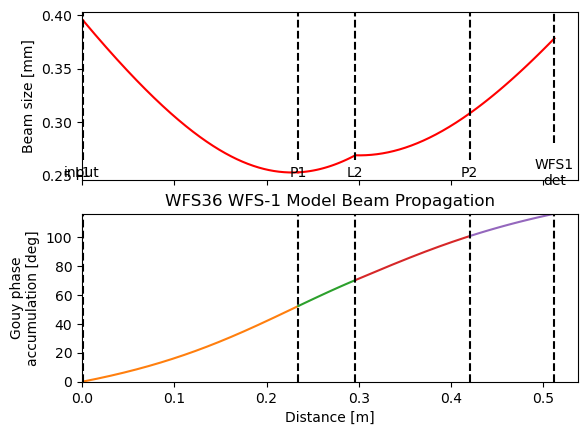

,z,w0,zr,w,RoC,S,Acc. Gouy,q
input.p1.i,0 m,331.52 um,324.51 mm,395.85 um,-709.09 mm,-1.4103 D,0°,-0.212 + 0.325j
input.p2.o,0 m,331.52 um,324.51 mm,395.85 um,-709.09 mm,-1.4103 D,0°,-0.212 + 0.325j
L1.p1.i,1 mm,331.52 um,324.51 mm,395.29 um,-710.45 mm,-1.4076 D,124.01m°,-0.211 + 0.325j
L1.p2.o,1 mm,252.74 um,188.6 mm,395.29 um,-383.64 mm,-2.6066 D,124.01m°,-0.227 + 0.189j
P1.p1.i,251 mm,252.74 um,188.6 mm,254.64 um,1.5572 m,642.16 mD,57.388°,0.023 + 0.189j
P1.p3.o,251 mm,252.74 um,188.6 mm,254.64 um,1.5572 m,642.16 mD,57.388°,0.023 + 0.189j
L2.p1.i,326.6 mm,252.74 um,188.6 mm,285.31 um,458.86 mm,2.1793 D,78.024°,0.099 + 0.189j
L2.p2.o,326.6 mm,284.12 um,238.35 mm,285.31 um,2.6265 m,380.74 mD,78.024°,0.022 + 0.238j
P2.p1.i,453.2 mm,284.12 um,238.35 mm,334.7 um,531.2 mm,1.8825 D,104.7°,0.148 + 0.238j
P2.p2.o,453.2 mm,284.12 um,238.35 mm,334.7 um,531.2 mm,1.8825 D,104.7°,0.148 + 0.238j



WFS1 predicted beam size : 0.5606 mm


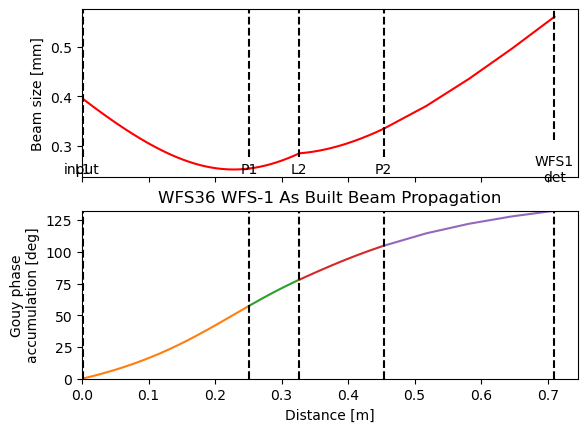

In [78]:
'''
WFS36 Gouy phase check for LLO HAM6, WFS-1 path.
Beam parameters from Phasics SID4 measurement at Input location.
Layout from D2100618-v1.
Path: input -> L1 -> P1 -> L2 -> P2 -> WFS1
'''

import finesse
import numpy as np
import matplotlib.pyplot as plt

WFS1 = finesse.Model()

WFS1.parse("""
# Input beam 
m input 0 1 0

# Free space from input to L1 lens 
s s_input_L1 input.p2 L1.p1 L=0.001

# L1: biconvex, f = +834mm
lens L1 0.834

# L1 -> P1: 233.32mm 
s s_L1_P1 L1.p2 P1.p1 L=0.23332

# P1: beamsplitter, 20% reflection, 80% transmission
bs P1 0.20 0.80 0 0

# P1 reflected port (p3) -> L2: 61.92mm 
s s_P1_L2 P1.p3 L2.p1 L=0.06192

# L2: plano-convex, f = +556mm
lens L2 0.556

# L2 -> P2: 124.00mm 
s s_L2_P2 L2.p2 P2.p1 L=0.12400

# P2: beamsplitter, 50% reflection, 50% transmission
bs P2 0.50 0.50 0 0

# P2 transmitted port (p2) -> WFS1: 92.00mm 
s s_P2_WFS1 P2.p2 WFS1_det.p1 L=0.09200

# WFS1 detector face 
m WFS1_det 0 1 0
""")

# Propagate to get Gouy accumulation

WFS1_design = WFS1.propagate_beam('input.p1.i', 'WFS1_det.p2.o', q_in=q_in)
WFS1_design.print()

n_wfs1 = WFS1.get('WFS1_det.p2.o')
w_wfs1    = WFS1_design.node_info[n_wfs1]['q'].w
gouy_wfs1 = np.degrees(WFS1_design.acc_gouy_up_to(n_wfs1))

print(f"\nWFS1 predicted beam size : {w_wfs1*1e3:.4f} mm")

WFS1_design.plot()
plt.title("WFS36 WFS-1 Model Beam Propagation")
plt.show()

'''
WFS36 Gouy phase check for LLO HAM6, WFS-1 path.
Beam parameters from Phasics SID4 measurement at Input location.
Layout from D2100618-v1.
Path: input -> L1 -> P1 -> L2 -> P2 -> WFS1
'''

WFS1 = finesse.Model()

WFS1.parse("""
# Input beam 
m input 0 1 0

# Free space from input to L1 lens 
s s_input_L1 input.p2 L1.p1 L=0.001

# L1: biconvex, f = +834mm
lens L1 0.834

# L1 -> P1: 250mm 
s s_L1_P1 L1.p2 P1.p1 L=0.250

# P1: beamsplitter, 20% reflection, 80% transmission
bs P1 0.20 0.80 0 0

# P1 reflected port (p3) -> L2: 75.6mm 
s s_P1_L2 P1.p3 L2.p1 L=0.0756

# L2: plano-convex, f = +556mm
lens L2 0.556

# L2 -> P2: 126.6mm 
s s_L2_P2 L2.p2 P2.p1 L=0.1266

# P2: beamsplitter, 50% reflection, 50% transmission
bs P2 0.50 0.50 0 0

# P2 transmitted port (p2) -> WFS1: 257mm 
s s_P2_WFS1 P2.p2 WFS1_det.p1 L=0.257

# WFS1 detector face 
m WFS1_det 0 1 0
""")


WFS1_built = WFS1.propagate_beam('input.p1.i', 'WFS1_det.p2.o', q_in=q_in)
WFS1_built .print()

n_wfs1 = WFS1.get('WFS1_det.p2.o')
w_wfs1    = WFS1_built .node_info[n_wfs1]['q'].w
gouy_wfs1 = np.degrees(WFS1_built .acc_gouy_up_to(n_wfs1))

print(f"\nWFS1 predicted beam size : {w_wfs1*1e3:.4f} mm")

WFS1_built .plot()
plt.title("WFS36 WFS-1 As Built Beam Propagation")
plt.show()

,z,w0,zr,w,RoC,S,Acc. Gouy,q
input.p1.i,0 m,331.52 um,324.51 mm,395.85 um,-709.09 mm,-1.4103 D,0°,-0.212 + 0.325j
input.p2.o,0 m,331.52 um,324.51 mm,395.85 um,-709.09 mm,-1.4103 D,0°,-0.212 + 0.325j
L1.p1.i,1 mm,331.52 um,324.51 mm,395.29 um,-710.45 mm,-1.4076 D,124.01m°,-0.211 + 0.325j
L1.p2.o,1 mm,252.74 um,188.6 mm,395.29 um,-383.64 mm,-2.6066 D,124.01m°,-0.227 + 0.189j
P1.p1.i,234.32 mm,252.74 um,188.6 mm,252.89 um,5.4727 m,182.73 mD,52.355°,0.007 + 0.189j
P1.p3.o,234.32 mm,252.74 um,188.6 mm,252.89 um,5.4727 m,182.73 mD,52.355°,0.007 + 0.189j
L2.p1.i,296.24 mm,252.74 um,188.6 mm,268.86 um,588.26 mm,1.6999 D,70.321°,0.068 + 0.189j
L2.p2.o,296.24 mm,268.8 um,213.33 mm,268.86 um,-10.138 m,-98.636 mD,70.321°,-0.004 + 0.213j
P2.p1.i,420.24 mm,268.8 um,213.33 mm,308.1 um,500.33 mm,1.9987 D,100.78°,0.120 + 0.213j
P2.p3.o,420.24 mm,268.8 um,213.33 mm,308.1 um,500.33 mm,1.9987 D,100.78°,0.120 + 0.213j



WFS2 predicted beam size : 0.7769 mm


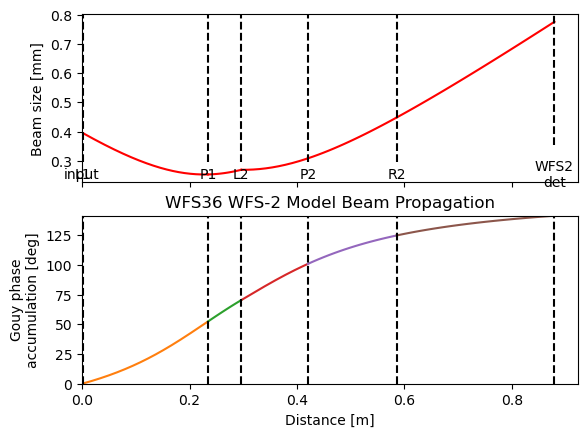

,z,w0,zr,w,RoC,S,Acc. Gouy,q
input.p1.i,0 m,331.52 um,324.51 mm,395.85 um,-709.09 mm,-1.4103 D,0°,-0.212 + 0.325j
input.p2.o,0 m,331.52 um,324.51 mm,395.85 um,-709.09 mm,-1.4103 D,0°,-0.212 + 0.325j
L1.p1.i,1 mm,331.52 um,324.51 mm,395.29 um,-710.45 mm,-1.4076 D,124.01m°,-0.211 + 0.325j
L1.p2.o,1 mm,252.74 um,188.6 mm,395.29 um,-383.64 mm,-2.6066 D,124.01m°,-0.227 + 0.189j
P1.p1.i,251 mm,252.74 um,188.6 mm,254.64 um,1.5572 m,642.16 mD,57.388°,0.023 + 0.189j
P1.p3.o,251 mm,252.74 um,188.6 mm,254.64 um,1.5572 m,642.16 mD,57.388°,0.023 + 0.189j
L2.p1.i,326.6 mm,252.74 um,188.6 mm,285.31 um,458.86 mm,2.1793 D,78.024°,0.099 + 0.189j
L2.p2.o,326.6 mm,284.12 um,238.35 mm,285.31 um,2.6265 m,380.74 mD,78.024°,0.022 + 0.238j
P2.p1.i,453.2 mm,284.12 um,238.35 mm,334.7 um,531.2 mm,1.8825 D,104.7°,0.148 + 0.238j
P2.p3.o,453.2 mm,284.12 um,238.35 mm,334.7 um,531.2 mm,1.8825 D,104.7°,0.148 + 0.238j



WFS2 predicted beam size : 0.9784 mm


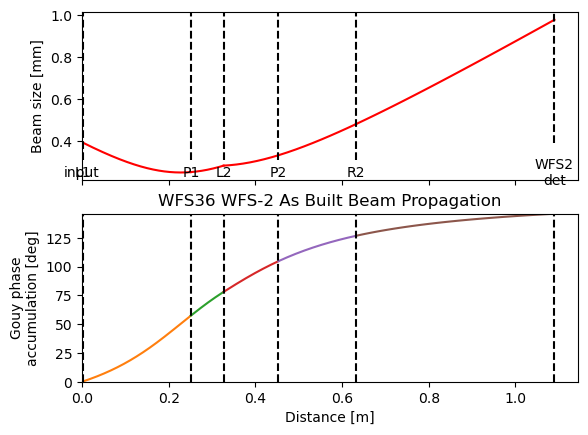

In [79]:
'''
WFS36 Gouy phase check for LLO HAM6, WFS-2 path.
Beam parameters from Phasics SID4 measurement at Input location.
Layout from D2100618-v1.
Path: input -> L1 -> P1 -> L2 -> P2 -> R2 -> WFS-2
'''

WFS2 = finesse.Model()

WFS2.parse("""
# Input beam 
m input 0 1 0

# Free space from input to L1 lens 
s s_input_L1 input.p2 L1.p1 L=0.001

# L1: biconvex, f = +834mm
lens L1 0.834

# L1 -> P1: 233.32mm 
s s_L1_P1 L1.p2 P1.p1 L=0.23332

# P1: beamsplitter, 20% reflection, 80% transmission
bs P1 0.20 0.80 0 0

# P1 reflected port (p3) -> L2: 61.92mm 
s s_P1_L2 P1.p3 L2.p1 L=0.06192

# L2: plano-convex, f = +556mm
lens L2 0.556

# L2 -> P2: 124.00mm 
s s_L2_P2 L2.p2 P2.p1 L=0.12400

# P2: beamsplitter, 50% reflection, 50% transmission
bs P2 0.50 0.50 0 0

# P2 reflected port (p3) -> R2: 165mm 
s s_P2_WFS1 P2.p3 R2.p1 L=0.165

# R2: flat mirror
m R2 1 0 0

# R2 reflected port p2 -> WFS2: 294.00mm 
s s_R2_WFS2 R2.p2 WFS2_det.p1 L=0.29400

# WFS2 detector face 
m WFS2_det 0 1 0
""")

WFS2_design = WFS2.propagate_beam('input.p1.i', 'WFS2_det.p2.o', q_in=q_in)
WFS2_design.print()

n_wfs1 = WFS2.get('WFS2_det.p2.o')
w_wfs1    = WFS2_design.node_info[n_wfs1]['q'].w
gouy_wfs1 = np.degrees(WFS2_design.acc_gouy_up_to(n_wfs1))

print(f"\nWFS2 predicted beam size : {w_wfs1*1e3:.4f} mm")

WFS2_design.plot()
plt.title("WFS36 WFS-2 Model Beam Propagation")
plt.show()

'''
WFS36 Gouy phase check for LLO HAM6, WFS-2 path.
Beam parameters from Phasics SID4 measurement at Input location.
Layout from D2100618-v1.
Path: input -> L1 -> P1 -> L2 -> P2 -> R2 -> WFS-2
'''

WFS2 = finesse.Model()

WFS2.parse("""
# Input beam 
m input 0 1 0

# Free space from input to L1 lens 
s s_input_L1 input.p2 L1.p1 L=0.001

# L1: biconvex, f = +834mm
lens L1 0.834

# L1 -> P1: 250mm 
s s_L1_P1 L1.p2 P1.p1 L=0.250

# P1: beamsplitter, 20% reflection, 80% transmission
bs P1 0.20 0.80 0 0

# P1 reflected port (p3) -> L2: 75.6mm 
s s_P1_L2 P1.p3 L2.p1 L=0.0756

# L2: plano-convex, f = +556mm
lens L2 0.556

# L2 -> P2: 126.6mm 
s s_L2_P2 L2.p2 P2.p1 L=0.1266

# P2: beamsplitter, 50% reflection, 50% transmission
bs P2 0.50 0.50 0 0

# P2 reflected port (p3) -> R2: 179mm 
s s_P2_WFS1 P2.p3 R2.p1 L=0.179

# R2: flat mirror
m R2 1 0 0

# R2 reflected port p2 -> WFS2: 458mm 
s s_R2_WFS2 R2.p2 WFS2_det.p1 L=0.458

# WFS2 detector face 
m WFS2_det 0 1 0
""")

WFS2_built = WFS2.propagate_beam('input.p1.i', 'WFS2_det.p2.o', q_in=q_in)
WFS2_built.print()

n_wfs1 = WFS2.get('WFS2_det.p2.o')
w_wfs1    = WFS2_built.node_info[n_wfs1]['q'].w
gouy_wfs1 = np.degrees(WFS2_built.acc_gouy_up_to(n_wfs1))

print(f"\nWFS2 predicted beam size : {w_wfs1*1e3:.4f} mm")

WFS2_built.plot()
plt.title("WFS36 WFS-2 As Built Beam Propagation")
plt.show()

Design PD1 position          : 348.2 mm
Model   beam radius @ PD1    : 0.3335 mm
As-built beam radius @ PD1   : 0.3335 mm
Model   Gouy @ PD1           : 116.99 (finesse units)
As-built Gouy @ PD1          : 117.02 (finesse units)


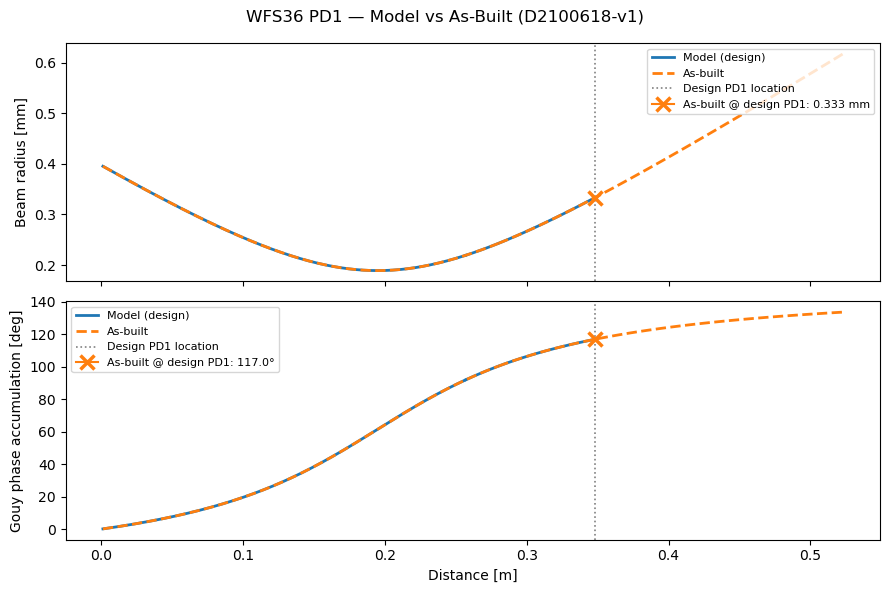

In [ ]:
''' PD1 Comparison '''

import matplotlib.ticker as ticker
import numpy as np

# ── extract finesse's own smooth line data via throwaway figures ──
fig_m,  axs_m  = PD1_design.plot()
fig_ab, axs_ab = PD1_built.plot()

# beam size: first line only (skip finesse's element markers / vlines)
def get_main_lines(ax):
    """Return only data lines (not vlines added by finesse for element boundaries).
    Finesse element markers are vertical lines with xdata of length 2 and
    constant x — filter them out by checking if xdata has > 2 points."""
    return [l for l in ax.get_lines() if len(l.get_xdata()) > 2]

m_w_lines  = get_main_lines(axs_m[0])
m_g_lines  = get_main_lines(axs_m[1])
ab_w_lines = get_main_lines(axs_ab[0])
ab_g_lines = get_main_lines(axs_ab[1])

plt.close(fig_m)
plt.close(fig_ab)

# ── as-built value at model PD1 distance ──
z_pd1_model = list(PD1_design.node_info.values())[-1]['z']   # metres
z_end_ab    = list(PD1_built.node_info.values())[-1]['z']
q_end_ab    = list(PD1_built.node_info.values())[-1]['q']
dz          = z_pd1_model - z_end_ab                       # negative: model is shorter

q_at_pd1  = finesse.BeamParam(q=q_end_ab.q + dz, wavelength=lam)
w_at_pd1  = q_at_pd1.w * 1e3   # mm

# read Gouy at model PD1 from the as-built plotted data (finesse's own units)
ab_g_xdata = np.concatenate([l.get_xdata() for l in ab_g_lines])
ab_g_ydata = np.concatenate([l.get_ydata() for l in ab_g_lines])
sort_idx   = np.argsort(ab_g_xdata)
ab_g_xdata = ab_g_xdata[sort_idx]
ab_g_ydata = ab_g_ydata[sort_idx]
idx        = np.argmin(np.abs(ab_g_xdata - z_pd1_model))
gouy_at_pd1 = ab_g_ydata[idx]

# model values at its own PD1 for reference
m_g_xdata = np.concatenate([l.get_xdata() for l in m_g_lines])
m_g_ydata = np.concatenate([l.get_ydata() for l in m_g_lines])
m_w_xdata = np.concatenate([l.get_xdata() for l in m_w_lines])
m_w_ydata = np.concatenate([l.get_ydata() for l in m_w_lines])
m_gouy_at_pd1 = m_g_ydata[np.argmin(np.abs(m_g_xdata - z_pd1_model))]
m_w_at_pd1    = m_w_ydata[np.argmin(np.abs(m_w_xdata - z_pd1_model))] 

print(f"Design PD1 position          : {z_pd1_model*1e3:.1f} mm")
print(f"Model   beam radius @ PD1    : {m_w_at_pd1:.4f} mm")
print(f"As-built beam radius @ PD1   : {w_at_pd1:.4f} mm")
print(f"Model   Gouy @ PD1           : {m_gouy_at_pd1:.2f} (finesse units)")
print(f"As-built Gouy @ PD1          : {gouy_at_pd1:.2f} (finesse units)")

# ── build clean overlay plot ──
fig, (ax_w, ax_g) = plt.subplots(2, 1, sharex=True, figsize=(9, 6))

# beam size panel
for i, line in enumerate(m_w_lines):
    ax_w.plot(line.get_xdata(), line.get_ydata(),
              color='C0', lw=2, label='Model (design)' if i == 0 else '_nolegend_')
for i, line in enumerate(ab_w_lines):
    ax_w.plot(line.get_xdata(), line.get_ydata(),
              color='C1', lw=2, ls='--', label='As-built' if i == 0 else '_nolegend_')

ax_w.axvline(z_pd1_model, color='gray', ls=':', lw=1.2, label='Design PD1 location')
ax_w.plot(z_pd1_model, w_at_pd1, marker='x', color='C1',
          ms=10, mew=2.5,
          label=f'As-built @ design PD1: {w_at_pd1:.3f} mm')
ax_w.set_ylabel('Beam radius [mm]')
ax_w.legend(fontsize=8, loc='upper right')

# Gouy panel
for i, line in enumerate(m_g_lines):
    ax_g.plot(line.get_xdata(), line.get_ydata(),
              color='C0', lw=2, label='Model (design)' if i == 0 else '_nolegend_')
for i, line in enumerate(ab_g_lines):
    ax_g.plot(line.get_xdata(), line.get_ydata(),
              color='C1', lw=2, ls='--', label='As-built' if i == 0 else '_nolegend_')

ax_g.axvline(z_pd1_model, color='gray', ls=':', lw=1.2, label='Design PD1 location')
ax_g.plot(z_pd1_model, gouy_at_pd1, marker='x', color='C1',
          ms=10, mew=2.5,
          label=f'As-built @ design PD1: {gouy_at_pd1:.1f}°')
ax_g.set_ylabel('Gouy phase accumulation [deg]')
ax_g.set_xlabel('Distance [m]')
ax_g.legend(fontsize=8, loc='upper left')

fig.suptitle('WFS36 PD1 (D2100618-v1) Model vs As-Built')
plt.tight_layout()
plt.show()

Design PD1 position          : 348.2 mm
Model   beam radius @ PD1    : 0.3335 mm
As-built beam radius @ PD1   : 0.3335 mm  (Δ=+0.0000 mm)
Model   Gouy @ PD1           : 116.99°
As-built Gouy @ PD1          : 117.02°  (Δ=+0.03°)


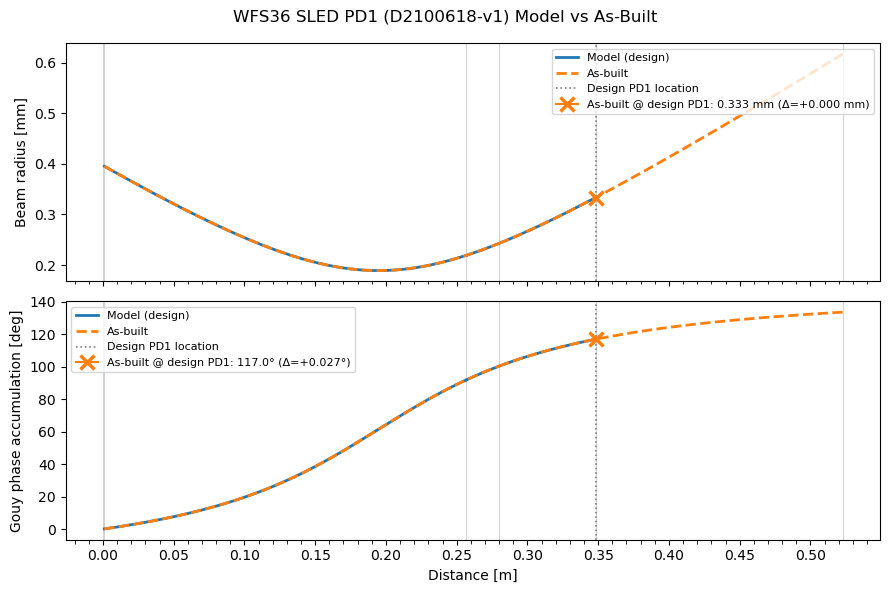

In [90]:
''' PD1 Comparison '''

import matplotlib.ticker as ticker
import numpy as np

# ── extract finesse's own smooth line data via throwaway figures ──
fig_m,  axs_m  = PD1_design.plot()
fig_ab, axs_ab = PD1_built.plot()

def get_main_lines(ax):
    """Data lines only — filter out finesse's 2-point element boundary vlines."""
    return [l for l in ax.get_lines() if len(l.get_xdata()) > 2]

def get_element_markers(ax):
    """Finesse's 2-point element boundary vlines only."""
    return [l for l in ax.get_lines() if len(l.get_xdata()) == 2]

m_w_lines  = get_main_lines(axs_m[0])
m_g_lines  = get_main_lines(axs_m[1])
ab_w_lines = get_main_lines(axs_ab[0])
ab_g_lines = get_main_lines(axs_ab[1])

# grab element markers BEFORE closing the throwaway figures
m_markers_w  = get_element_markers(axs_m[0])
m_markers_g  = get_element_markers(axs_m[1])
ab_markers_w = get_element_markers(axs_ab[0])
ab_markers_g = get_element_markers(axs_ab[1])

plt.close(fig_m)
plt.close(fig_ab)

# ── as-built value at design PD1 distance ──
z_pd1_model = list(PD1_design.node_info.values())[-1]['z']
z_end_ab    = list(PD1_built.node_info.values())[-1]['z']
q_end_ab    = list(PD1_built.node_info.values())[-1]['q']
dz          = z_pd1_model - z_end_ab

q_at_pd1 = finesse.BeamParam(q=q_end_ab.q + dz, wavelength=lam)
w_at_pd1 = q_at_pd1.w * 1e3   # mm

# Gouy at design PD1: read from as-built plotted data
ab_g_xdata = np.concatenate([l.get_xdata() for l in ab_g_lines])
ab_g_ydata = np.concatenate([l.get_ydata() for l in ab_g_lines])
sort_idx   = np.argsort(ab_g_xdata)
ab_g_xdata = ab_g_xdata[sort_idx]
ab_g_ydata = ab_g_ydata[sort_idx]
gouy_at_pd1 = ab_g_ydata[np.argmin(np.abs(ab_g_xdata - z_pd1_model))]

# model values at PD1 for delta calculation
m_g_xdata = np.concatenate([l.get_xdata() for l in m_g_lines])
m_g_ydata = np.concatenate([l.get_ydata() for l in m_g_lines])
m_w_xdata = np.concatenate([l.get_xdata() for l in m_w_lines])
m_w_ydata = np.concatenate([l.get_ydata() for l in m_w_lines])
m_gouy_at_pd1 = m_g_ydata[np.argmin(np.abs(m_g_xdata - z_pd1_model))]
m_w_at_pd1    = m_w_ydata[np.argmin(np.abs(m_w_xdata - z_pd1_model))]

delta_w    = w_at_pd1 - m_w_at_pd1
delta_gouy = gouy_at_pd1 - m_gouy_at_pd1

print(f"Design PD1 position          : {z_pd1_model*1e3:.1f} mm")
print(f"Model   beam radius @ PD1    : {m_w_at_pd1:.4f} mm")
print(f"As-built beam radius @ PD1   : {w_at_pd1:.4f} mm  (Δ={delta_w:+.4f} mm)")
print(f"Model   Gouy @ PD1           : {m_gouy_at_pd1:.2f}°")
print(f"As-built Gouy @ PD1          : {gouy_at_pd1:.2f}°  (Δ={delta_gouy:+.2f}°)")

# ── build clean overlay plot ──
fig, (ax_w, ax_g) = plt.subplots(2, 1, sharex=True, figsize=(9, 6))

# --- element boundary markers (drawn first so they sit behind data) ---
seen_w = set()
for line in m_markers_w + ab_markers_w:
    x = line.get_xdata()[0]
    if x not in seen_w:                          # avoid double-drawing same position
        ax_w.axvline(x, color='lightgray', ls='-', lw=0.8, zorder=0)
        seen_w.add(x)

seen_g = set()
for line in m_markers_g + ab_markers_g:
    x = line.get_xdata()[0]
    if x not in seen_g:
        ax_g.axvline(x, color='lightgray', ls='-', lw=0.8, zorder=0)
        seen_g.add(x)

# --- beam size panel ---
for i, line in enumerate(m_w_lines):
    ax_w.plot(line.get_xdata(), line.get_ydata(),
              color='C0', lw=2,
              label='Model (design)' if i == 0 else '_nolegend_')
for i, line in enumerate(ab_w_lines):
    ax_w.plot(line.get_xdata(), line.get_ydata(),
              color='C1', lw=2, ls='--',
              label='As-built' if i == 0 else '_nolegend_')

ax_w.axvline(z_pd1_model, color='gray', ls=':', lw=1.2,
             label='Design PD1 location')
ax_w.plot(z_pd1_model, w_at_pd1, marker='x', color='C1', ms=10, mew=2.5,
          label=f'As-built @ design PD1: {w_at_pd1:.3f} mm (Δ={delta_w:+.3f} mm)')
ax_w.set_ylabel('Beam radius [mm]')
ax_w.legend(fontsize=8, loc='upper right')

# --- Gouy panel ---
for i, line in enumerate(m_g_lines):
    ax_g.plot(line.get_xdata(), line.get_ydata(),
              color='C0', lw=2,
              label='Model (design)' if i == 0 else '_nolegend_')
for i, line in enumerate(ab_g_lines):
    ax_g.plot(line.get_xdata(), line.get_ydata(),
              color='C1', lw=2, ls='--',
              label='As-built' if i == 0 else '_nolegend_')

ax_g.axvline(z_pd1_model, color='gray', ls=':', lw=1.2,
             label='Design PD1 location')
ax_g.plot(z_pd1_model, gouy_at_pd1, marker='x', color='C1', ms=10, mew=2.5,
          label=f'As-built @ design PD1: {gouy_at_pd1:.1f}° (Δ={delta_gouy:+.3f}°)')
ax_g.set_ylabel('Gouy phase accumulation [deg]')
ax_g.set_xlabel('Distance [m]')
ax_g.legend(fontsize=8, loc='upper left')

# --- axis ticks ---
ax_g.xaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax_g.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))
ax_g.tick_params(which='minor', length=3)

fig.suptitle('WFS36 SLED PD1 (D2100618-v1) Model vs As-Built')
plt.tight_layout()
plt.show()

Design PD1 position          : 512.2 mm
Model   beam radius @ WFS1    : 0.3785 mm
As-built beam radius @ WFS1   : 0.3767 mm  (Δ=-0.0019 mm)
Model   Gouy @ PD1           : 116.28°
As-built Gouy @ PD1          : 114.54°  (Δ=-1.74°)


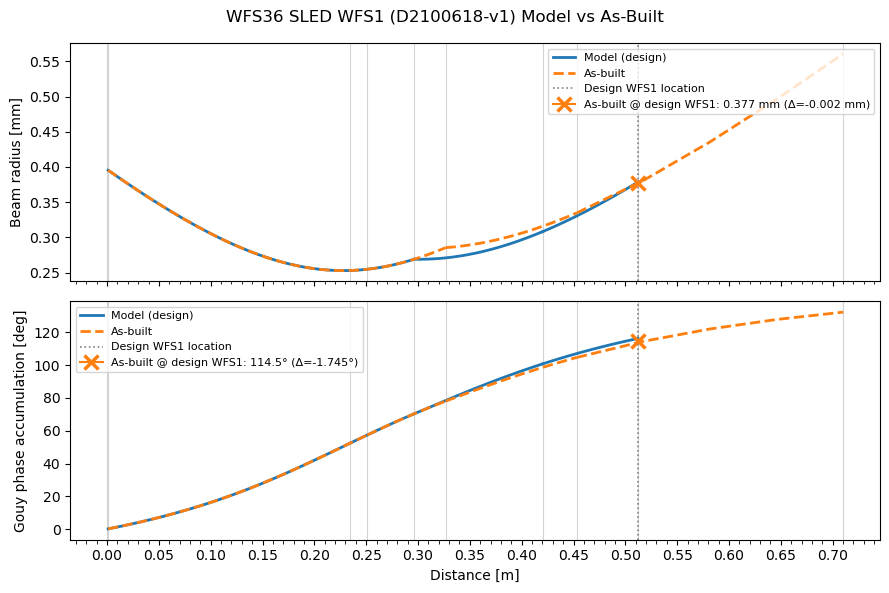

In [ ]:
''' WFS-1 Comparison '''

import matplotlib.ticker as ticker
import numpy as np

# ── extract finesse's own smooth line data via throwaway figures ──
fig_m,  axs_m  = WFS1_design.plot()
fig_ab, axs_ab = WFS1_built.plot()

def get_main_lines(ax):
    """Data lines only — filter out finesse's 2-point element boundary vlines."""
    return [l for l in ax.get_lines() if len(l.get_xdata()) > 2]

def get_element_markers(ax):
    """Finesse's 2-point element boundary vlines only."""
    return [l for l in ax.get_lines() if len(l.get_xdata()) == 2]

m_w_lines  = get_main_lines(axs_m[0])
m_g_lines  = get_main_lines(axs_m[1])
ab_w_lines = get_main_lines(axs_ab[0])
ab_g_lines = get_main_lines(axs_ab[1])

# grab element markers BEFORE closing the throwaway figures
m_markers_w  = get_element_markers(axs_m[0])
m_markers_g  = get_element_markers(axs_m[1])
ab_markers_w = get_element_markers(axs_ab[0])
ab_markers_g = get_element_markers(axs_ab[1])

plt.close(fig_m)
plt.close(fig_ab)

# ── as-built value at design PD1 distance ──
z_pd1_model = list(WFS1_design.node_info.values())[-1]['z']
z_end_ab    = list(WFS1_built.node_info.values())[-1]['z']
q_end_ab    = list(WFS1_built.node_info.values())[-1]['q']
dz          = z_pd1_model - z_end_ab

q_at_pd1 = finesse.BeamParam(q=q_end_ab.q + dz, wavelength=lam)
w_at_pd1 = q_at_pd1.w * 1e3   # mm

# Gouy at design WFS1: read from as-built plotted data
ab_g_xdata = np.concatenate([l.get_xdata() for l in ab_g_lines])
ab_g_ydata = np.concatenate([l.get_ydata() for l in ab_g_lines])
sort_idx   = np.argsort(ab_g_xdata)
ab_g_xdata = ab_g_xdata[sort_idx]
ab_g_ydata = ab_g_ydata[sort_idx]
gouy_at_pd1 = ab_g_ydata[np.argmin(np.abs(ab_g_xdata - z_pd1_model))]

# model values at WFS1 for delta calculation
m_g_xdata = np.concatenate([l.get_xdata() for l in m_g_lines])
m_g_ydata = np.concatenate([l.get_ydata() for l in m_g_lines])
m_w_xdata = np.concatenate([l.get_xdata() for l in m_w_lines])
m_w_ydata = np.concatenate([l.get_ydata() for l in m_w_lines])
m_gouy_at_pd1 = m_g_ydata[np.argmin(np.abs(m_g_xdata - z_pd1_model))]
m_w_at_pd1    = m_w_ydata[np.argmin(np.abs(m_w_xdata - z_pd1_model))]

delta_w    = w_at_pd1 - m_w_at_pd1
delta_gouy = gouy_at_pd1 - m_gouy_at_pd1

print(f"Design WFS1 position          : {z_pd1_model*1e3:.1f} mm")
print(f"Model   beam radius @ WFS1    : {m_w_at_pd1:.4f} mm")
print(f"As-built beam radius @ WFS1   : {w_at_pd1:.4f} mm  (Δ={delta_w:+.4f} mm)")
print(f"Model   Gouy @ WFS1           : {m_gouy_at_pd1:.2f}°")
print(f"As-built Gouy @ WFS1          : {gouy_at_pd1:.2f}°  (Δ={delta_gouy:+.2f}°)")

# ── build clean overlay plot ──
fig, (ax_w, ax_g) = plt.subplots(2, 1, sharex=True, figsize=(9, 6))

# --- element boundary markers (drawn first so they sit behind data) ---
seen_w = set()
for line in m_markers_w + ab_markers_w:
    x = line.get_xdata()[0]
    if x not in seen_w:                          # avoid double-drawing same position
        ax_w.axvline(x, color='lightgray', ls='-', lw=0.8, zorder=0)
        seen_w.add(x)

seen_g = set()
for line in m_markers_g + ab_markers_g:
    x = line.get_xdata()[0]
    if x not in seen_g:
        ax_g.axvline(x, color='lightgray', ls='-', lw=0.8, zorder=0)
        seen_g.add(x)

# --- beam size panel ---
for i, line in enumerate(m_w_lines):
    ax_w.plot(line.get_xdata(), line.get_ydata(),
              color='C0', lw=2,
              label='Model (design)' if i == 0 else '_nolegend_')
for i, line in enumerate(ab_w_lines):
    ax_w.plot(line.get_xdata(), line.get_ydata(),
              color='C1', lw=2, ls='--',
              label='As-built' if i == 0 else '_nolegend_')

ax_w.axvline(z_pd1_model, color='gray', ls=':', lw=1.2,
             label='Design WFS1 location')
ax_w.plot(z_pd1_model, w_at_pd1, marker='x', color='C1', ms=10, mew=2.5,
          label=f'As-built @ design WFS1: {w_at_pd1:.3f} mm (Δ={delta_w:+.3f} mm)')
ax_w.set_ylabel('Beam radius [mm]')
ax_w.legend(fontsize=8, loc='upper right')

# --- Gouy panel ---
for i, line in enumerate(m_g_lines):
    ax_g.plot(line.get_xdata(), line.get_ydata(),
              color='C0', lw=2,
              label='Model (design)' if i == 0 else '_nolegend_')
for i, line in enumerate(ab_g_lines):
    ax_g.plot(line.get_xdata(), line.get_ydata(),
              color='C1', lw=2, ls='--',
              label='As-built' if i == 0 else '_nolegend_')

ax_g.axvline(z_pd1_model, color='gray', ls=':', lw=1.2,
             label='Design WFS1 location')
ax_g.plot(z_pd1_model, gouy_at_pd1, marker='x', color='C1', ms=10, mew=2.5,
          label=f'As-built @ design WFS1: {gouy_at_pd1:.1f}° (Δ={delta_gouy:+.3f}°)')
ax_g.set_ylabel('Gouy phase accumulation [deg]')
ax_g.set_xlabel('Distance [m]')
ax_g.legend(fontsize=8, loc='upper left')

# --- axis ticks ---
ax_g.xaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax_g.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))
ax_g.tick_params(which='minor', length=3)

fig.suptitle('WFS36 SLED WFS1 (D2100618-v1) Model vs As-Built')
plt.tight_layout()
plt.show()

Design WFS2 position          : 879.2 mm
Model   beam radius @ WFS2    : 0.7769 mm
As-built beam radius @ WFS2   : 0.7414 mm  (Δ=-0.0355 mm)
Model   Gouy @ WFS2           : 141.28°
As-built Gouy @ WFS2          : 140.25°  (Δ=-1.04°)


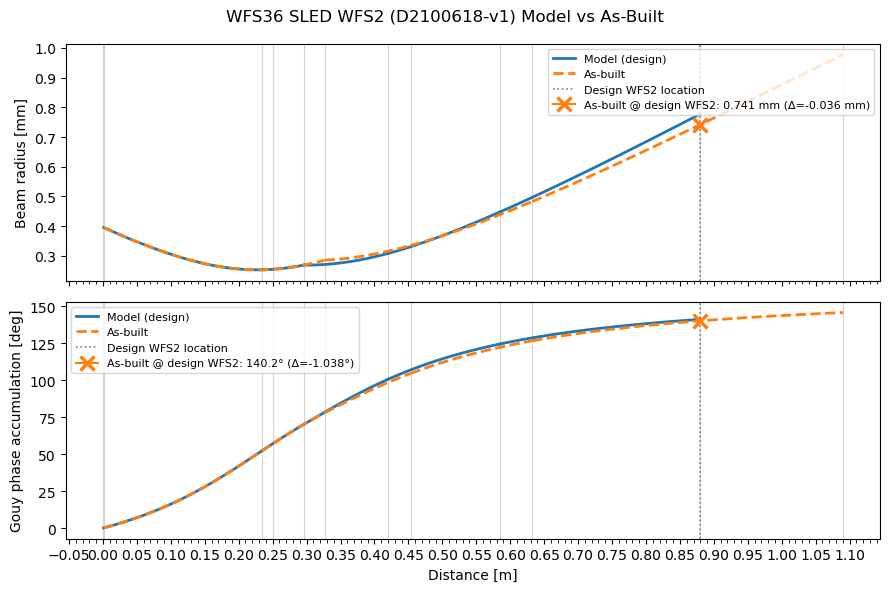

In [ ]:
''' WFS-2 Comparison '''

import matplotlib.ticker as ticker
import numpy as np

# ── extract finesse's own smooth line data via throwaway figures ──
fig_m,  axs_m  = WFS2_design.plot()
fig_ab, axs_ab = WFS2_built.plot()

def get_main_lines(ax):
    """Data lines only — filter out finesse's 2-point element boundary vlines."""
    return [l for l in ax.get_lines() if len(l.get_xdata()) > 2]

def get_element_markers(ax):
    """Finesse's 2-point element boundary vlines only."""
    return [l for l in ax.get_lines() if len(l.get_xdata()) == 2]

m_w_lines  = get_main_lines(axs_m[0])
m_g_lines  = get_main_lines(axs_m[1])
ab_w_lines = get_main_lines(axs_ab[0])
ab_g_lines = get_main_lines(axs_ab[1])

# grab element markers BEFORE closing the throwaway figures
m_markers_w  = get_element_markers(axs_m[0])
m_markers_g  = get_element_markers(axs_m[1])
ab_markers_w = get_element_markers(axs_ab[0])
ab_markers_g = get_element_markers(axs_ab[1])

plt.close(fig_m)
plt.close(fig_ab)

# ── as-built value at design PD1 distance ──
z_pd1_model = list(WFS2_design.node_info.values())[-1]['z']
z_end_ab    = list(WFS2_built.node_info.values())[-1]['z']
q_end_ab    = list(WFS2_built.node_info.values())[-1]['q']
dz          = z_pd1_model - z_end_ab

q_at_pd1 = finesse.BeamParam(q=q_end_ab.q + dz, wavelength=lam)
w_at_pd1 = q_at_pd1.w * 1e3   # mm

# Gouy at design WFS2: read from as-built plotted data
ab_g_xdata = np.concatenate([l.get_xdata() for l in ab_g_lines])
ab_g_ydata = np.concatenate([l.get_ydata() for l in ab_g_lines])
sort_idx   = np.argsort(ab_g_xdata)
ab_g_xdata = ab_g_xdata[sort_idx]
ab_g_ydata = ab_g_ydata[sort_idx]
gouy_at_pd1 = ab_g_ydata[np.argmin(np.abs(ab_g_xdata - z_pd1_model))]

# model values at WFS2 for delta calculation
m_g_xdata = np.concatenate([l.get_xdata() for l in m_g_lines])
m_g_ydata = np.concatenate([l.get_ydata() for l in m_g_lines])
m_w_xdata = np.concatenate([l.get_xdata() for l in m_w_lines])
m_w_ydata = np.concatenate([l.get_ydata() for l in m_w_lines])
m_gouy_at_pd1 = m_g_ydata[np.argmin(np.abs(m_g_xdata - z_pd1_model))]
m_w_at_pd1    = m_w_ydata[np.argmin(np.abs(m_w_xdata - z_pd1_model))]

delta_w    = w_at_pd1 - m_w_at_pd1
delta_gouy = gouy_at_pd1 - m_gouy_at_pd1

print(f"Design WFS2 position          : {z_pd1_model*1e3:.1f} mm")
print(f"Model   beam radius @ WFS2    : {m_w_at_pd1:.4f} mm")
print(f"As-built beam radius @ WFS2   : {w_at_pd1:.4f} mm  (Δ={delta_w:+.4f} mm)")
print(f"Model   Gouy @ WFS2           : {m_gouy_at_pd1:.2f}°")
print(f"As-built Gouy @ WFS2          : {gouy_at_pd1:.2f}°  (Δ={delta_gouy:+.2f}°)")

# ── build clean overlay plot ──
fig, (ax_w, ax_g) = plt.subplots(2, 1, sharex=True, figsize=(9, 6))

# --- element boundary markers (drawn first so they sit behind data) ---
seen_w = set()
for line in m_markers_w + ab_markers_w:
    x = line.get_xdata()[0]
    if x not in seen_w:                          # avoid double-drawing same position
        ax_w.axvline(x, color='lightgray', ls='-', lw=0.8, zorder=0)
        seen_w.add(x)

seen_g = set()
for line in m_markers_g + ab_markers_g:
    x = line.get_xdata()[0]
    if x not in seen_g:
        ax_g.axvline(x, color='lightgray', ls='-', lw=0.8, zorder=0)
        seen_g.add(x)

# --- beam size panel ---
for i, line in enumerate(m_w_lines):
    ax_w.plot(line.get_xdata(), line.get_ydata(),
              color='C0', lw=2,
              label='Model (design)' if i == 0 else '_nolegend_')
for i, line in enumerate(ab_w_lines):
    ax_w.plot(line.get_xdata(), line.get_ydata(),
              color='C1', lw=2, ls='--',
              label='As-built' if i == 0 else '_nolegend_')

ax_w.axvline(z_pd1_model, color='gray', ls=':', lw=1.2,
             label='Design WFS2 location')
ax_w.plot(z_pd1_model, w_at_pd1, marker='x', color='C1', ms=10, mew=2.5,
          label=f'As-built @ design WFS2: {w_at_pd1:.3f} mm (Δ={delta_w:+.3f} mm)')
ax_w.set_ylabel('Beam radius [mm]')
ax_w.legend(fontsize=8, loc='upper right')

# --- Gouy panel ---
for i, line in enumerate(m_g_lines):
    ax_g.plot(line.get_xdata(), line.get_ydata(),
              color='C0', lw=2,
              label='Model (design)' if i == 0 else '_nolegend_')
for i, line in enumerate(ab_g_lines):
    ax_g.plot(line.get_xdata(), line.get_ydata(),
              color='C1', lw=2, ls='--',
              label='As-built' if i == 0 else '_nolegend_')

ax_g.axvline(z_pd1_model, color='gray', ls=':', lw=1.2,
             label='Design WFS2 location')
ax_g.plot(z_pd1_model, gouy_at_pd1, marker='x', color='C1', ms=10, mew=2.5,
          label=f'As-built @ design WFS2: {gouy_at_pd1:.1f}° (Δ={delta_gouy:+.3f}°)')
ax_g.set_ylabel('Gouy phase accumulation [deg]')
ax_g.set_xlabel('Distance [m]')
ax_g.legend(fontsize=8, loc='upper left')

# --- axis ticks ---
ax_g.xaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax_g.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))
ax_g.tick_params(which='minor', length=3)

fig.suptitle('WFS36 SLED WFS2 (D2100618-v1) Model vs As-Built')
plt.tight_layout()
plt.show()